# Análisis de Frecuencias

Extraemos los n-gramas más frecuentes del dataset sin partir de una lista de palabras predefinida. La idea es dejar que los datos indiquen qué términos separan mejor las dos clases, en lugar de asumirlo de antemano.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from src.analisis_frecuencias import get_top_ngrams

df = pd.read_csv("../data/cleaned/train_cleaned.csv")
disaster_tweets = df[df['target'] == 1]['text']
normal_tweets = df[df['target'] == 0]['text']


## 1. Unigramas más frecuentes por clase

/tmp/ipykernel_206516/721234684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_disaster, x='count', y='ngram', ax=axes[0], palette='Reds_d')
/tmp/ipykernel_206516/721234684.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_normal, x='count', y='ngram', ax=axes[1], palette='Blues_d')


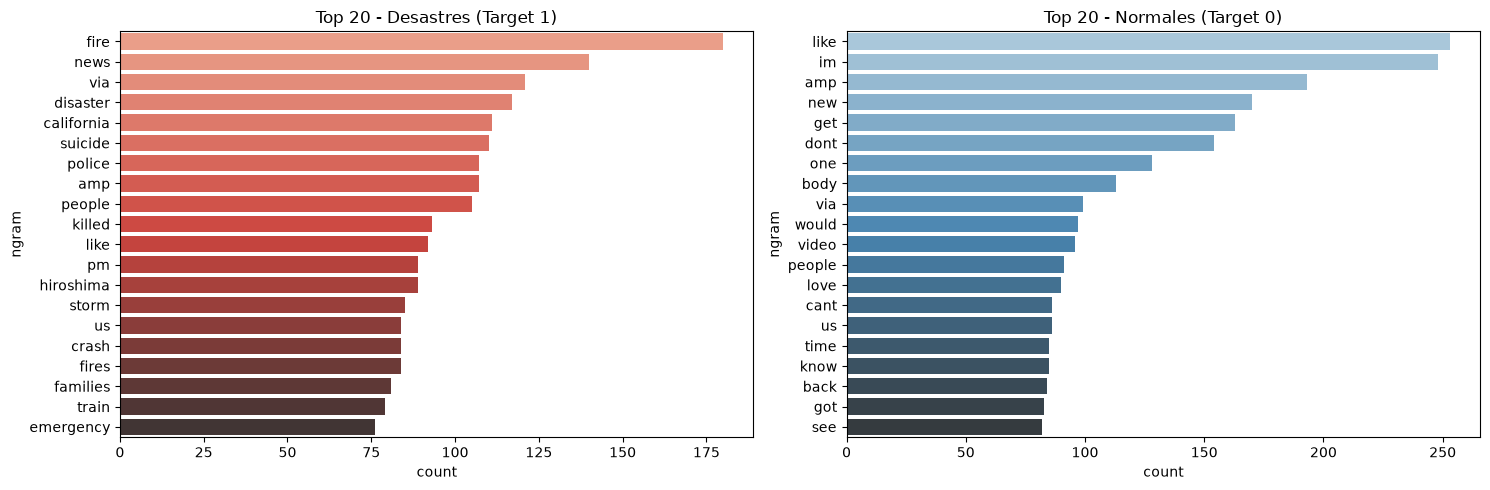

In [2]:
top_disaster = get_top_ngrams(disaster_tweets, ngram_range=(1,1), top_k=20)
top_normal = get_top_ngrams(normal_tweets, ngram_range=(1,1), top_k=20)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=top_disaster, x='count', y='ngram', ax=axes[0], palette='Reds_d')
axes[0].set_title('Top 20 - Desastres (Target 1)')

sns.barplot(data=top_normal, x='count', y='ngram', ax=axes[1], palette='Blues_d')
axes[1].set_title('Top 20 - Normales (Target 0)')

plt.tight_layout()
plt.show()


## 2. Bigramas y trigramas en la clase desastre

/tmp/ipykernel_206516/4067129317.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bigrams, x='count', y='ngram', ax=axes[0], palette='Reds_d')
/tmp/ipykernel_206516/4067129317.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_trigrams, x='count', y='ngram', ax=axes[1], palette='Oranges_d')


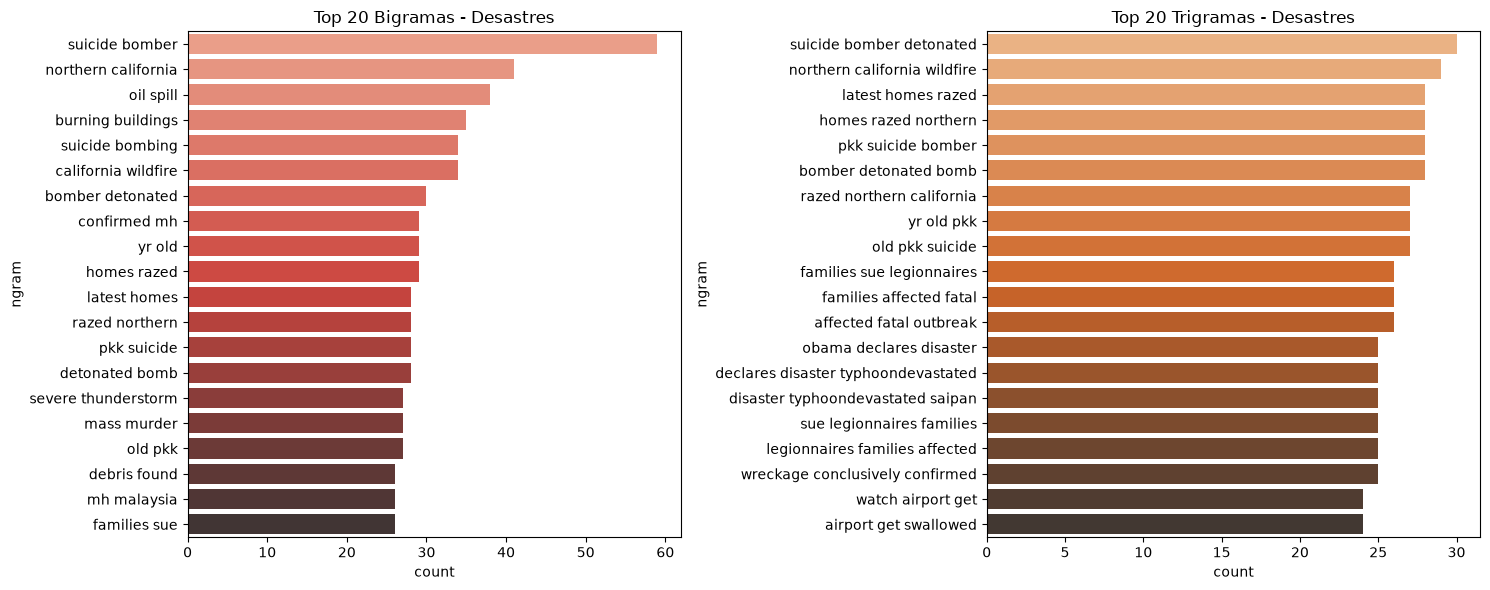

In [3]:
top_bigrams = get_top_ngrams(disaster_tweets, ngram_range=(2,2), top_k=20)
top_trigrams = get_top_ngrams(disaster_tweets, ngram_range=(3,3), top_k=20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=top_bigrams, x='count', y='ngram', ax=axes[0], palette='Reds_d')
axes[0].set_title('Top 20 Bigramas - Desastres')

sns.barplot(data=top_trigrams, x='count', y='ngram', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Top 20 Trigramas - Desastres')

plt.tight_layout()
plt.show()


## Notas sobre frecuencias

**¿Qué palabras discriminan mejor?**

En la clase 0 predominan términos coloquiales de uso general: *like*, *im*, *amp*, *new*, *get*, *dont*. Al ser frecuentes en cualquier conversación, aportan poca capacidad de separación. La clase 1 concentra en cambio vocabulario específico de eventos: *fire*, *news*, *disaster*, *california*, *suicide*, *police*, *killed*. Son estos términos concretos los que esperamos que carguen el peso en el clasificador.

**Bigramas y trigramas**

Los bigramas agrupan conceptos legibles: *suicide bomber* (59 apariciones), *northern california* (41). A nivel descriptivo muestran un contexto que el unigrama suelto no deja ver.

Los trigramas se comportan distinto. Secuencias como *latest homes razed* se repiten unas 30 veces de forma casi idéntica, algo que no corresponde a lenguaje espontáneo sino a cuentas automatizadas y cadenas de noticias replicando el mismo titular. Un modelo entrenado sobre ellos se ajustaría a las noticias puntuales del periodo en que se recolectó el dataset.

Queda pendiente comprobar si esta lectura descriptiva se traduce en mejor desempeño predictivo: que un n-grama sea legible para nosotros no garantiza que ayude al modelo. Esa prueba se hace en `modelos_clasificacion.ipynb`, entrenando con los tres rangos de n-gramas y comparando resultados.